## Load ERA5 single-level reanalysis from GCP cloud storage

Following the docs on
* https://console.cloud.google.com/marketplace/product/bigquery-public-data/arco-era5
* https://github.com/google-research/arco-era5/blob/main/docs/0-Surface-Reanalysis-Walkthrough.ipynb

In [1]:
import xarray

single_reanalysis = xarray.open_zarr(
    "gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr",
    chunks={'time': 48}, 
    consolidated=True,
)
single_reanalysis

<xarray.Dataset>
Dimensions:              (time: 374016, values: 542080)
Coordinates:
    depthBelowLandLayer  float64 ...
    entireAtmosphere     float64 ...
    latitude             (values) float64 dask.array<chunksize=(542080,), meta=np.ndarray>
    longitude            (values) float64 dask.array<chunksize=(542080,), meta=np.ndarray>
    number               int64 ...
    step                 timedelta64[ns] ...
    surface              float64 ...
  * time                 (time) datetime64[ns] 1979-01-01 ... 2021-08-31T23:0...
    valid_time           (time) datetime64[ns] dask.array<chunksize=(48,), meta=np.ndarray>
Dimensions without coordinates: values
Data variables: (12/38)
    cape                 (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    d2m                  (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    hcc                  (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl1                (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl2                (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    istl3                (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    ...                   ...
    tsn                  (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    u10                  (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    u100                 (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    v10                  (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    v100                 (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
    z                    (time, values) float32 dask.array<chunksize=(48, 542080), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.7
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    GRIB_edition:              1
    GRIB_subCentre:            0
    history:                   2022-09-23T18:56 GRIB to CDM+CF via cfgrib-0.9...
    institution:               European Centre for Medium-Range Weather Forec...
    pangeo-forge:inputs_hash:  5f4378143e9f42402424280b63472752da3aa79179b53b...
    pangeo-forge:recipe_hash:  0c3415923e347ce9dac9dc5c6d209525f4d45d799bd25b...
    pangeo-forge:version:      0.9.1

## List all the data variables and their long names

In [2]:
for name in single_reanalysis.data_vars.keys():
    print((name, single_reanalysis[name].attrs["long_name"]))

('cape', 'Convective available potential energy')
('d2m', '2 metre dewpoint temperature')
('hcc', 'High cloud cover')
('istl1', 'Ice temperature layer 1')
('istl2', 'Ice temperature layer 2')
('istl3', 'Ice temperature layer 3')
('istl4', 'Ice temperature layer 4')
('lcc', 'Low cloud cover')
('mcc', 'Medium cloud cover')
('msl', 'Mean sea level pressure')
('p79.162', 'Vertical integral of divergence of cloud liquid water flux')
('p80.162', 'Vertical integral of divergence of cloud frozen water flux')
('siconc', 'Sea ice area fraction')
('skt', 'Skin temperature')
('sp', 'Surface pressure')
('sst', 'Sea surface temperature')
('stl1', 'Soil temperature level 1')
('stl2', 'Soil temperature level 2')
('stl3', 'Soil temperature level 3')
('stl4', 'Soil temperature level 4')
('swvl1', 'Volumetric soil water layer 1')
('swvl2', 'Volumetric soil water layer 2')
('swvl3', 'Volumetric soil water layer 3')
('swvl4', 'Volumetric soil water layer 4')
('t2m', '2 metre temperature')
('tcc', 'Total cl

## Select a variable and time slice (last available)

In [3]:
da = single_reanalysis["t2m"].isel(time=-1)

## Plot data on Gaussian grid with scatter

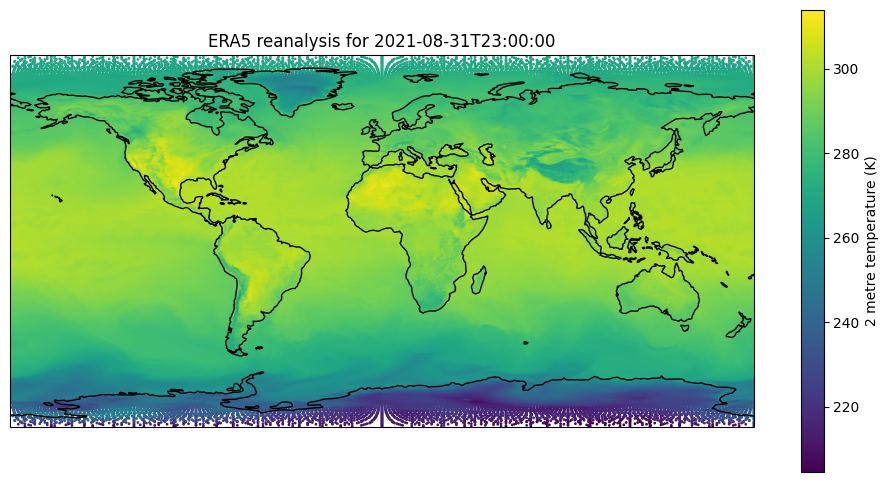

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
scatter = plt.scatter(
    da.longitude,
    da.latitude,
    c=da.values,
    s=1
)
plt.colorbar(scatter, label="{long_name} ({units})".format(**da.attrs))
ax.coastlines()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"ERA5 reanalysis for {np.datetime_as_string(da.time.values[()], unit='s')}") ;